Antal utan m-komponent i träningsdatan: 4528
Antal med m-komponent i träningsdatan: 1605
Total parameters: 320,194
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   0 | train: 0.7415 | val: 0.6739 | acc: 77.98% | AUC: 0.800  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   1 | train: 0.4988 | val: 0.5536 | acc: 81.26% | AUC: 0.848  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   2 | train: 0.3498 | val: 0.5076 | acc: 85.39% | AUC: 0.877  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   3 | train: 0.3055 | val: 0.3467 | acc: 91.21% | AUC: 0.918  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   4 | train: 0.2406 | val: 0.3261 | acc: 92.45% | AUC: 0.935  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   5 | train: 0.2133 | val: 0.3209 | acc: 92.89% | AUC: 0.93

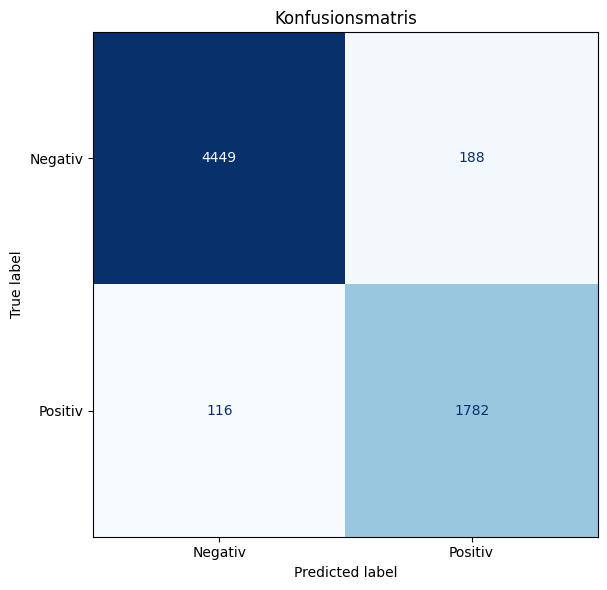

AUC: 0.9810475505923968
Accuracy:  95.35%
FN-rate:   6.11%  (farliga missade fall)
FP-rate:   4.05%  (onödiga larm)
Sensitivitet:   93.89%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   95.95%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9810


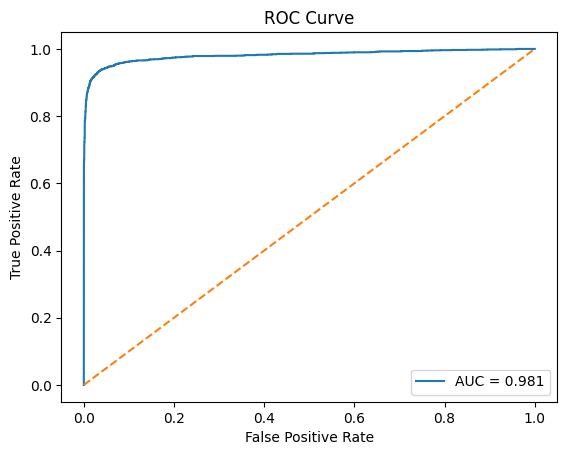

In [1]:
import duckdb
from networks.cnn_dataset_experiment import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']


train_rows = train_rows[train_rows['label'].isin([0,1])]
drop_indices = train_rows.sample(frac=0.95).index
train_rows = train_rows.drop(drop_indices)
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)
result = CNN.predict(val_rows)
_ = CNN.evaluate(result)


Antal utan m-komponent i träningsdatan: 9128
Antal med m-komponent i träningsdatan: 3139
Total parameters: 320,194
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   0 | train: 0.5125 | val: 0.5086 | acc: 85.87% | AUC: 0.882  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   1 | train: 0.2661 | val: 0.2485 | acc: 94.04% | AUC: 0.963  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   2 | train: 0.1878 | val: 0.1771 | acc: 95.21% | AUC: 0.976  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   3 | train: 0.1468 | val: 0.1630 | acc: 96.26% | AUC: 0.982  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   4 | train: 0.1289 | val: 0.1417 | acc: 96.22% | AUC: 0.986  | LR: 0.001
Epoch   5 | train: 0.1168 | val: 0.1488 | acc: 96.40% | AUC: 0.983  | LR: 0.001
Epoch   6 | train: 0.1148 | val: 0.1394 | acc: 95.96% |

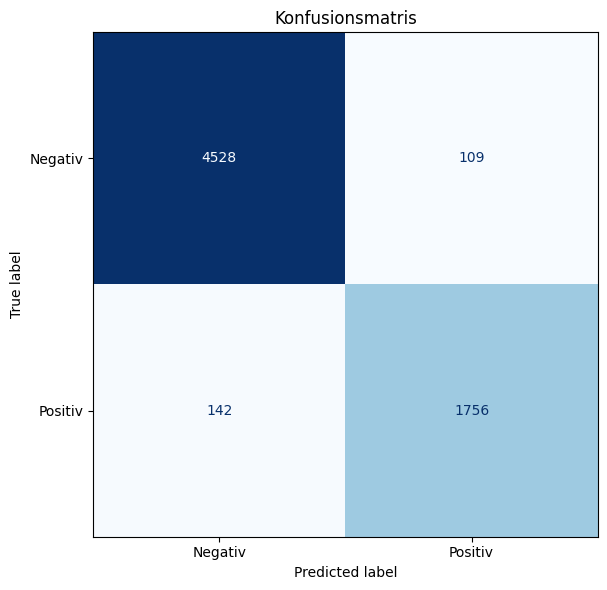

AUC: 0.9855703187332931
Accuracy:  96.16%
FN-rate:   7.48%  (farliga missade fall)
FP-rate:   2.35%  (onödiga larm)
Sensitivitet:   92.52%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   97.65%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9856


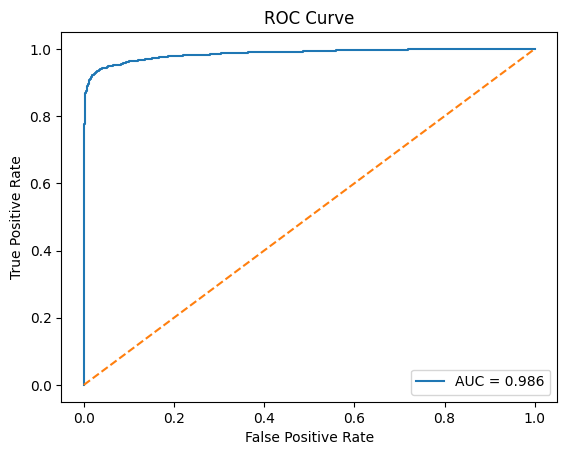

In [2]:
import duckdb
from networks.cnn_dataset_experiment import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']


train_rows = train_rows[train_rows['label'].isin([0,1])]
drop_indices = train_rows.sample(frac=0.9).index
train_rows = train_rows.drop(drop_indices)

val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

result = CNN.predict(val_rows)
_ = CNN.evaluate(result)

Antal utan m-komponent i träningsdatan: 18149
Antal med m-komponent i träningsdatan: 6384
Total parameters: 320,194
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   0 | train: 0.4326 | val: 0.3037 | acc: 91.78% | AUC: 0.931  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   1 | train: 0.2040 | val: 0.1989 | acc: 94.93% | AUC: 0.968  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   2 | train: 0.1407 | val: 0.1575 | acc: 95.24% | AUC: 0.978  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   3 | train: 0.1199 | val: 0.1403 | acc: 96.09% | AUC: 0.982  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   4 | train: 0.1079 | val: 0.1483 | acc: 96.43% | AUC: 0.984  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   5 | train: 0.1123 | val: 0.1322 | acc: 96.32% | AUC: 0.9

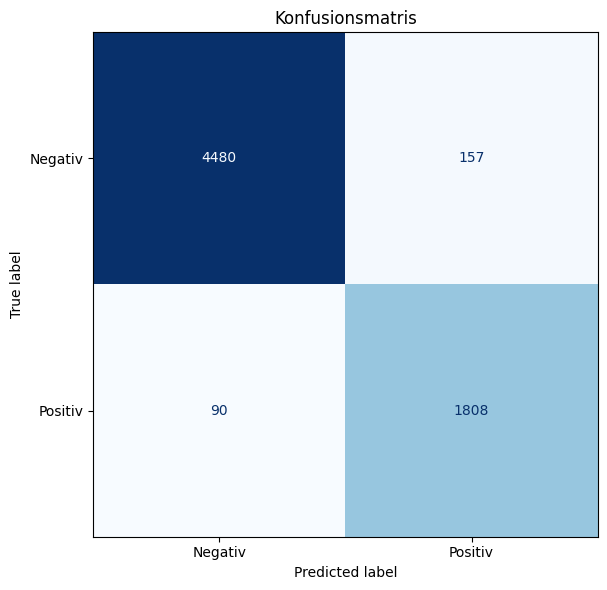

AUC: 0.9869214680197513
Accuracy:  96.22%
FN-rate:   4.74%  (farliga missade fall)
FP-rate:   3.39%  (onödiga larm)
Sensitivitet:   95.26%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   96.61%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9869


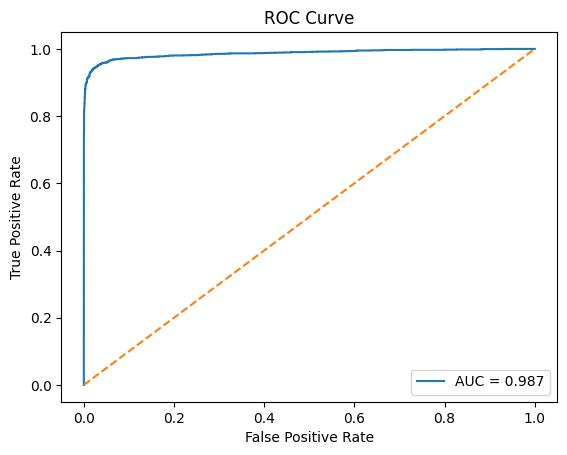

In [3]:
import duckdb
from networks.cnn_dataset_experiment import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']


train_rows = train_rows[train_rows['label'].isin([0,1])]
drop_indices = train_rows.sample(frac=0.8).index
train_rows = train_rows.drop(drop_indices)

val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

result = CNN.predict(val_rows)
_ = CNN.evaluate(result)

Antal utan m-komponent i träningsdatan: 22762
Antal med m-komponent i träningsdatan: 7904
Total parameters: 320,194
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   0 | train: 0.4341 | val: 0.2746 | acc: 92.31% | AUC: 0.941  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   1 | train: 0.2227 | val: 0.1506 | acc: 95.79% | AUC: 0.983  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   2 | train: 0.1631 | val: 0.1520 | acc: 95.60% | AUC: 0.983  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   3 | train: 0.1529 | val: 0.1387 | acc: 96.42% | AUC: 0.985  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   4 | train: 0.1423 | val: 0.1337 | acc: 96.25% | AUC: 0.985  | LR: 0.001
Epoch   5 | train: 0.1343 | val: 0.1508 | acc: 96.75% | AUC: 0.983  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset

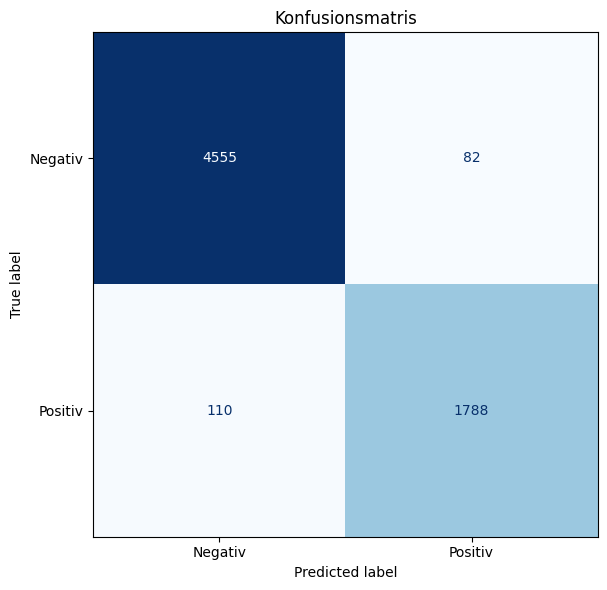

AUC: 0.9876007638200365
Accuracy:  97.06%
FN-rate:   5.80%  (farliga missade fall)
FP-rate:   1.77%  (onödiga larm)
Sensitivitet:   94.20%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   98.23%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9876


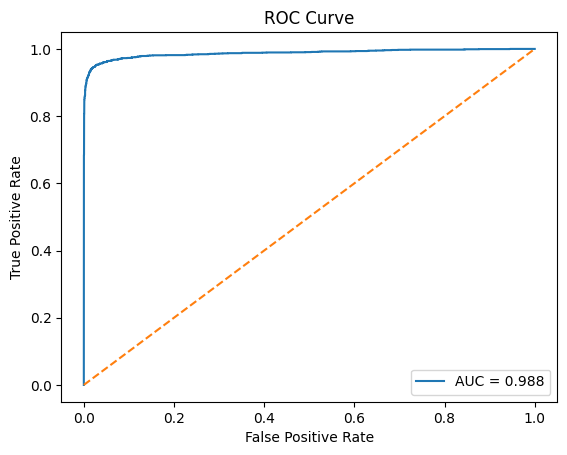

In [4]:
import duckdb
from networks.cnn_dataset_experiment import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']


train_rows = train_rows[train_rows['label'].isin([0,1])]
drop_indices = train_rows.sample(frac=0.75).index
train_rows = train_rows.drop(drop_indices)

val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

result = CNN.predict(val_rows)
_ = CNN.evaluate(result)

Antal utan m-komponent i träningsdatan: 45530
Antal med m-komponent i träningsdatan: 15803
Total parameters: 320,194
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   0 | train: 0.2442 | val: 0.1529 | acc: 95.62% | AUC: 0.981  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   1 | train: 0.1228 | val: 0.1295 | acc: 96.34% | AUC: 0.985  | LR: 0.001
Epoch   2 | train: 0.1138 | val: 0.1351 | acc: 95.62% | AUC: 0.983  | LR: 0.001
Epoch   3 | train: 0.1030 | val: 0.1334 | acc: 96.74% | AUC: 0.984  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   4 | train: 0.0978 | val: 0.1170 | acc: 96.57% | AUC: 0.987  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   5 | train: 0.0932 | val: 0.1154 | acc: 96.86% | AUC: 0.988  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   6 | train: 0.0887 | val: 0.1255 | acc: 96.83%

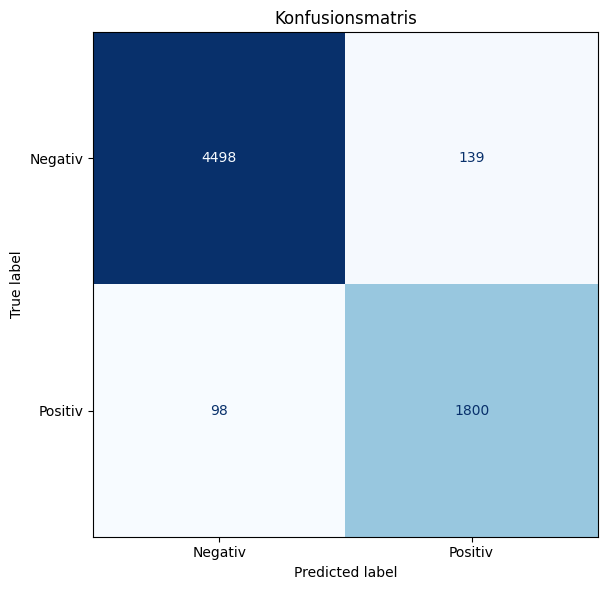

AUC: 0.9871359884631634
Accuracy:  96.37%
FN-rate:   5.16%  (farliga missade fall)
FP-rate:   3.00%  (onödiga larm)
Sensitivitet:   94.84%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   97.00%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9871


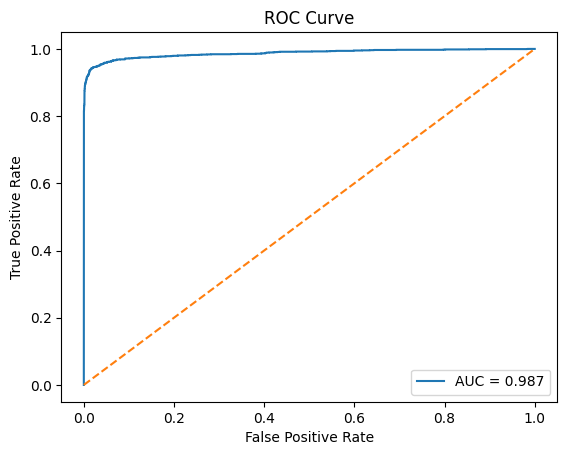

In [5]:
import duckdb
from networks.cnn_dataset_experiment import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']


train_rows = train_rows[train_rows['label'].isin([0,1])]
drop_indices = train_rows.sample(frac=0.5).index
train_rows = train_rows.drop(drop_indices)

val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

result = CNN.predict(val_rows)
_ = CNN.evaluate(result)

Antal utan m-komponent i träningsdatan: 68151
Antal med m-komponent i träningsdatan: 23848
Total parameters: 320,194
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   0 | train: 0.2279 | val: 0.1620 | acc: 96.40% | AUC: 0.985  | LR: 0.001
Epoch   1 | train: 0.1179 | val: 0.1419 | acc: 96.91% | AUC: 0.985  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   2 | train: 0.1077 | val: 0.1228 | acc: 96.54% | AUC: 0.986  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   3 | train: 0.0974 | val: 0.1158 | acc: 97.04% | AUC: 0.988  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   4 | train: 0.0945 | val: 0.1162 | acc: 95.96% | AUC: 0.989  | LR: 0.001
Epoch   5 | train: 0.0911 | val: 0.1238 | acc: 97.49% | AUC: 0.986  | LR: 0.001
Epoch   6 | train: 0.0896 | val: 0.1224 | acc: 96.49% | AUC: 0.987  | LR: 0.001
Epoch   7 | train: 0.0874 | val: 0.1259 | a

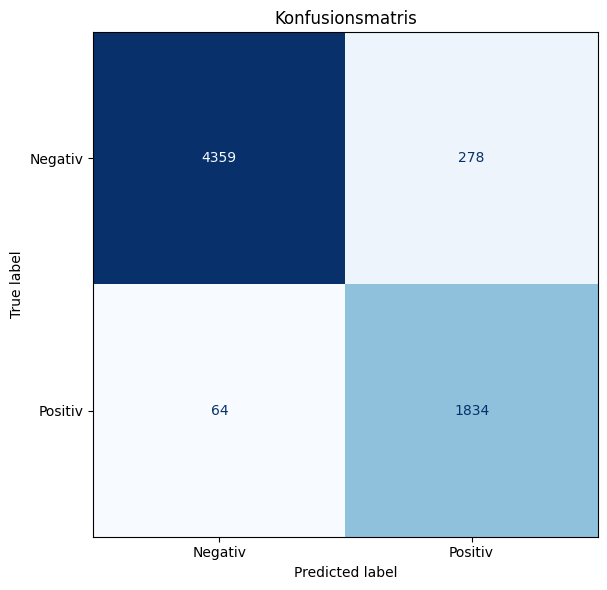

AUC: 0.9874987302616763
Accuracy:  94.77%
FN-rate:   3.37%  (farliga missade fall)
FP-rate:   6.00%  (onödiga larm)
Sensitivitet:   96.63%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   94.00%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9875


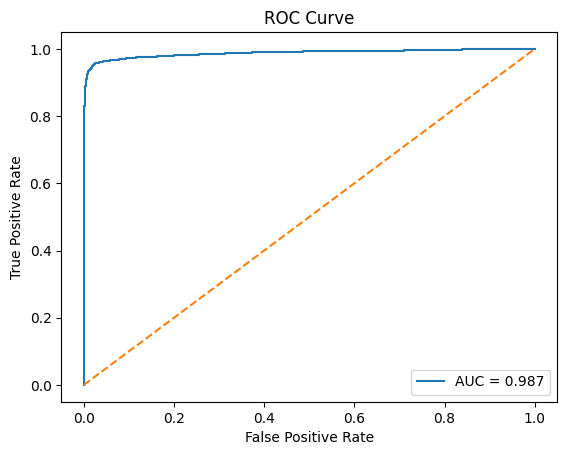

In [6]:
import duckdb
from networks.cnn_dataset_experiment import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']


train_rows = train_rows[train_rows['label'].isin([0,1])]
drop_indices = train_rows.sample(frac=0.25).index
train_rows = train_rows.drop(drop_indices)

val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

result = CNN.predict(val_rows)
_ = CNN.evaluate(result)

In [ ]:
import duckdb
from networks.cnn_dataset_experiment import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']


train_rows = train_rows[train_rows['label'].isin([0,1])]


val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

result = CNN.predict(val_rows)
_ = CNN.evaluate(result)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Antal utan m-komponent i träningsdatan: 90907
Antal med m-komponent i träningsdatan: 31758
Total parameters: 320,194
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   0 | train: 0.2483 | val: 0.1821 | acc: 96.37% | AUC: 0.981  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   1 | train: 0.1261 | val: 0.1270 | acc: 96.51% | AUC: 0.987  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   2 | train: 0.1133 | val: 0.1147 | acc: 96.94% | AUC: 0.988  | LR: 0.001
Epoch   3 | train: 0.1038 | val: 0.1266 | acc: 96.97% | AUC: 0.987  | LR: 0.001
Epoch   4 | train: 0.0991 | val: 0.1263 | acc: 96.98% | AUC: 0.985  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   5 | train: 0.0949 | val: 0.1107 | acc: 97.06% | AUC: 0.989  | LR: 0.001
Epoch   6 | train: 0.0910 | val: 0.1109 | acc: 97.21% | AUC: 0.988  | LR: 0.001
  -> ny bästa modell sparad till ../models/

In [ ]:
import duckdb
from networks.cnn_dataset_experiment import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']


train_rows = train_rows[train_rows['label'].isin([0,1])]
drop_indices = train_rows.sample(frac=0.99).index
train_rows = train_rows.drop(drop_indices)

val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

result = CNN.predict(val_rows)
_ = CNN.evaluate(result)